# Supply Chain GHG Emission Factors — Feasibility Checkpoint

## Dataset

**Source:** U.S. EPA Supply Chain Greenhouse Gas Emission Factors (USEEIO model)  
**Link:** https://www.epa.gov/climateleadership/supply-chain-ghg-emission-factors-us-commodities-and-industries  

The EPA publishes industry-level GHG emission factors derived from its USEEIO input-output model. Each row maps a 2017 NAICS industry code to a supply-chain emission factor expressed in **kg CO2-equivalent emitted per USD of economic output** (purchaser price).

### Files used

| File | Description |
|---|---|
| `SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv` | All GHGs collapsed to CO₂e, 2021 USD baseline |
| `SupplyChainGHGEmissionFactors_v1.3.0_NAICS_CO2e_USD2022.csv` | Same structure, updated to 2022 USD baseline |
| `SupplyChainGHGEmissionFactors_v1.3.0_NAICS_byGHG_USD2022.csv` | Broken out by individual GHG (18 gases × 1016 industries) |

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## 1. Load the Data

In [10]:
DATA = "datasets/"

v22   = pd.read_csv(DATA + "SupplyChainGHGEmissionFactors_v1.3.0_NAICS_CO2e_USD2022.csv")
byghg = pd.read_csv(DATA + "SupplyChainGHGEmissionFactors_v1.3.0_NAICS_byGHG_USD2022.csv")

RENAME = {
    "2017 NAICS Code": "naics_code",
    "2017 NAICS Title": "industry",
    "GHG": "ghg",
    "Unit": "unit",
    "Supply Chain Emission Factors without Margins": "ef_no_margin",
    "Margins of Supply Chain Emission Factors": "ef_margin",
    "Supply Chain Emission Factors with Margins": "ef_with_margin",
    "Reference USEEIO Code": "useeio_code",
}
v22   = v22.rename(columns=RENAME)
byghg = byghg.rename(columns=RENAME)

print(f"v1.3 CO₂e (2022 USD): {v22.shape[0]:,} rows × {v22.shape[1]} cols")
print(f"v1.3 by-GHG (supplementary): {byghg.shape[0]:,} rows × {byghg.shape[1]} cols")

v1.3 CO₂e (2022 USD): 1,016 rows × 8 cols
v1.3 by-GHG (supplementary): 18,288 rows × 8 cols


### First few rows — CO₂e file (2022 USD)

In [11]:
v22.head(10)

,naics_code,industry,ghg,unit,ef_no_margin,ef_margin,ef_with_margin,useeio_code
0,111110,Soybean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
1,111120,Oilseed (except Soybean) Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
2,111130,Dry Pea and Bean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
3,111140,Wheat Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
4,111150,Corn Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
5,111160,Rice Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
6,111191,Oilseed and Grain Combination Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
7,111199,All Other Grain Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
8,111211,Potato Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.591,0.041,0.631,111200
9,111219,Other Vegetable (except Potato) and Melon Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.591,0.041,0.631,111200


### Summary statistics (2022 USD CO₂e)

In [12]:
v22[["ef_no_margin", "ef_margin", "ef_with_margin"]].describe().round(4)

,ef_no_margin,ef_margin,ef_with_margin
count,1016.0000,1016.0000,1016.0000
mean,0.2650,0.0169,0.2819
std,0.3148,0.0234,0.3214
min,0.0260,0.0000,0.0290
25%,0.1030,0.0000,0.1080
50%,0.1590,0.0000,0.1730
75%,0.3022,0.0302,0.3293
max,3.8460,0.1250,3.9240


### 1b. 3-Digit NAICS Aggregation

Aggregating to 3-digit NAICS (median emission factor per sector) is the primary analytical lens — procurement audiences can act at this level, and the sector medians directly feed the supplier risk score. The 6-digit breakdown remains available for subindustry drill-downs.

In [13]:
v22["naics3"] = v22["naics_code"].astype(str).str[:3]

# First industry title per 3-digit group gives a readable sector label
sector_label = v22.groupby("naics3")["industry"].first()

df3 = (
    v22.groupby("naics3")["ef_with_margin"]
    .agg(median="median", mean="mean", n_subindustries="count")
    .join(sector_label)
    .reset_index()
    .sort_values("median", ascending=False)
)

print(f"3-digit sectors: {len(df3)}  (from {len(v22)} 6-digit industries)")
df3.head(10)[["naics3", "industry", "median", "mean", "n_subindustries"]]

3-digit sectors: 90  (from 1016 6-digit industries)


,naics3,industry,median,mean,n_subindustries
53,486,Pipeline Transportation of Crude Oil,1.6190,1.619000,4
1,112,Beef Cattle Ranching and Farming,1.1280,1.256474,19
76,562,Solid Waste Collection,0.9880,0.988000,11
50,483,Deep Sea Freight Transportation,0.8160,0.816000,6
48,481,Scheduled Passenger Air Transportation,0.6440,0.644000,5
51,484,"General Freight Trucking, Local",0.5950,0.595000,6
0,111,Soybean Farming,0.5815,0.607133,30
8,221,Natural Gas Distribution,0.5780,0.566500,4
52,485,Mixed Mode Transit Systems,0.5660,0.566000,11
24,327,"Pottery, Ceramics, and Plumbing Fixture Manufa...",0.5470,0.783222,18


## 2. Visualizations

### 2a. Distribution of emission factors

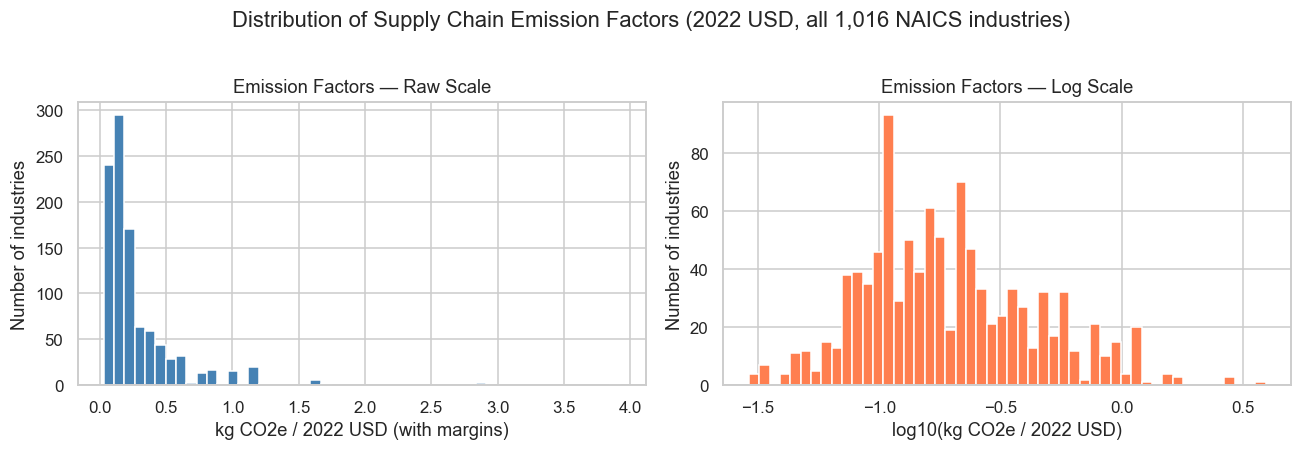

Range:  0.029 - 3.924 kg CO2e/USD
Median: 0.173   Mean: 0.282


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(v22["ef_with_margin"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("kg CO2e / 2022 USD (with margins)")
axes[0].set_ylabel("Number of industries")
axes[0].set_title("Emission Factors — Raw Scale")

log_ef = np.log10(v22["ef_with_margin"])
axes[1].hist(log_ef, bins=50, color="coral", edgecolor="white")
axes[1].set_xlabel("log10(kg CO2e / 2022 USD)")
axes[1].set_ylabel("Number of industries")
axes[1].set_title("Emission Factors — Log Scale")

plt.suptitle("Distribution of Supply Chain Emission Factors (2022 USD, all 1,016 NAICS industries)", y=1.02)
plt.tight_layout()
plt.show()

print(f"Range:  {v22['ef_with_margin'].min():.3f} - {v22['ef_with_margin'].max():.3f} kg CO2e/USD")
print(f"Median: {v22['ef_with_margin'].median():.3f}   Mean: {v22['ef_with_margin'].mean():.3f}")

### 2b. Top 20 Most Carbon-Intensive Sectors — 3-Digit NAICS

/var/folders/7h/p2y091tx0_v962lmb2pdsdy40000gn/T/ipykernel_4235/3779540882.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/Users/owainwilliams/Developer/CSE151Project/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


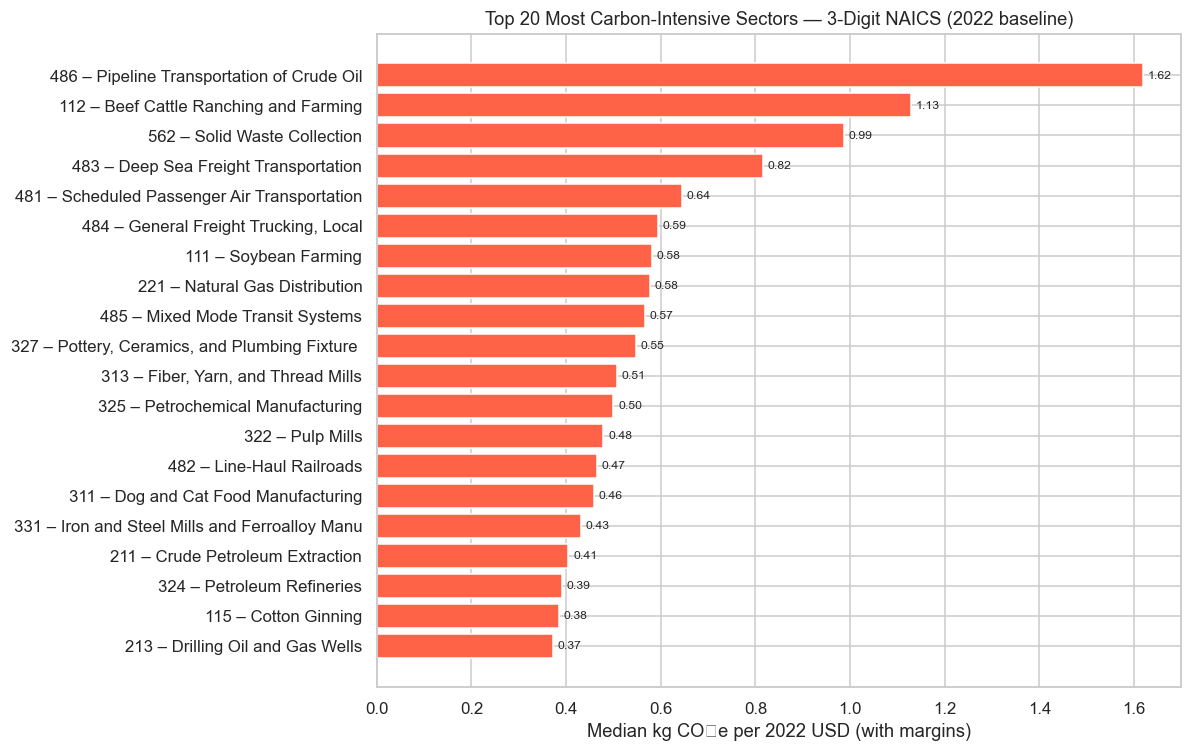

In [15]:
top20 = df3.nlargest(20, "median").reset_index(drop=True)
labels = top20["naics3"] + " – " + top20["industry"].str[:40]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(labels[::-1], top20["median"][::-1], color="tomato")
ax.set_xlabel("Median kg CO₂e per 2022 USD (with margins)")
ax.set_title("Top 20 Most Carbon-Intensive Sectors — 3-Digit NAICS (2022 baseline)")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

### 2c. Bottom 20 Least Carbon-Intensive Sectors — 3-Digit NAICS

/var/folders/7h/p2y091tx0_v962lmb2pdsdy40000gn/T/ipykernel_4235/3780409332.py:9: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


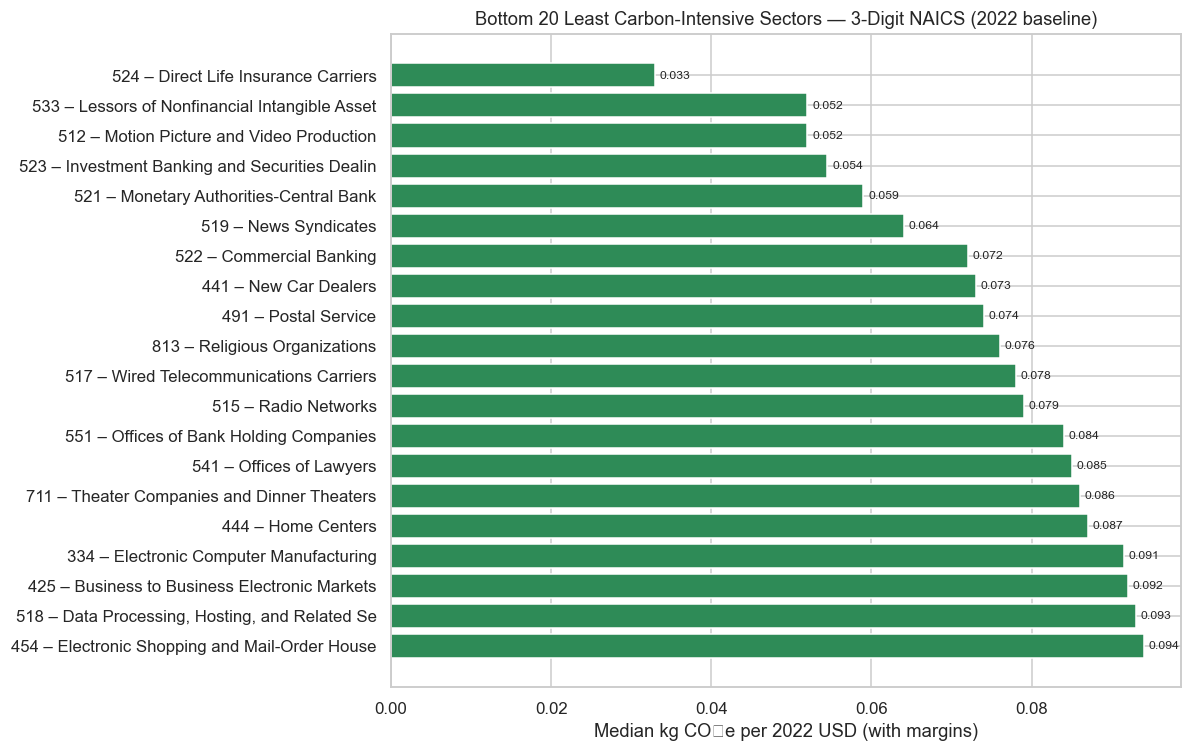

In [16]:
bot20 = df3.nsmallest(20, "median").reset_index(drop=True)
labels = bot20["naics3"] + " – " + bot20["industry"].str[:40]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(labels[::-1], bot20["median"][::-1], color="seagreen")
ax.set_xlabel("Median kg CO₂e per 2022 USD (with margins)")
ax.set_title("Bottom 20 Least Carbon-Intensive Sectors — 3-Digit NAICS (2022 baseline)")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

### 2d. GHG Composition — Supplementary Note

Carbon dioxide and methane dominate aggregate supply-chain emissions across all sectors; the remaining 16 gases (HFCs, PFCs, etc.) are minor in aggregate but can be material within specific sectors (e.g., methane-intensive livestock, refrigerant-heavy cold-chain logistics). The `byghg` dataframe is available for sector-specific gas drill-downs but is not part of the primary supplier risk score.

## 3. Key Takeaways

- The dataset covers **1,016 NAICS 6-digit industries**, collapsed to **90 3-digit sectors** — the sector level is the primary analytical lens for a procurement audience.
- Emission factors span **roughly two orders of magnitude** (~0.03 to ~4 kg CO₂e/USD), with a heavily right-skewed distribution. Agriculture and energy-intensive sectors are the dominant outliers.
- **2022 USD baseline** (v1.3) is the single reference year. The 2021 → 2022 shift is a deflator adjustment, not a real emissions change, so year-over-year comparison adds no analytical value.
- **Carbon dioxide and methane** dominate aggregate supply-chain emissions; gas-specific breakdown is available in `byghg` for supplementary context.
- 3-digit sector median emission factors directly feed the supplier risk score — high-emission sectors (e.g., coal mining, livestock, petroleum) warrant elevated risk weights; low-emission sectors (e.g., software, finance, healthcare) can be down-weighted.

## 4. Predictive Model — Emission Risk Classification

**Goal:** Given a new supplier's industry description and 2-digit NAICS sector, classify their emission risk as **Low / Medium / High** and return class probabilities. This operationalizes the supplier risk score for procurement use.

**Features**
| Feature | Encoding | Rationale |
|---|---|---|
| Industry name | TF-IDF unigrams + bigrams | Captures semantic content ("mining," "software," "cattle") |
| 2-digit NAICS sector | One-hot | Encodes major economic division without data leakage |

**Target** — tertile split of `ef_with_margin` into three equal-frequency risk tiers (Low / Medium / High).

**Model** — multinomial logistic regression (`lbfgs`, L2 regularization, C = 1.0).

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Tertile-based risk tiers: equal-frequency Low / Medium / High
lo_cut, hi_cut = v22["ef_with_margin"].quantile([1/3, 2/3])
v22["risk_tier"] = pd.cut(
    v22["ef_with_margin"],
    bins=[-np.inf, lo_cut, hi_cut, np.inf],
    labels=["Low", "Medium", "High"],
)

print(v22["risk_tier"].value_counts().sort_index())
print(f"\nThresholds — Low ≤ {lo_cut:.3f} < Medium ≤ {hi_cut:.3f} < High  (kg CO₂e / 2022 USD)")

risk_tier
Low       344
Medium    338
High      334
Name: count, dtype: int64

Thresholds — Low ≤ 0.120 < Medium ≤ 0.246 < High  (kg CO₂e / 2022 USD)


In [18]:
v22["sector2"] = v22["naics_code"].astype(str).str[:2]

X = v22[["industry", "sector2"]]
y = v22["risk_tier"].astype(str)

preprocessor = ColumnTransformer([
    ("tfidf",   TfidfVectorizer(ngram_range=(1, 2)), "industry"),
    ("sector2", OneHotEncoder(handle_unknown="ignore"), ["sector2"]),
])

pipe = Pipeline([
    ("features", preprocessor),
    ("clf",      LogisticRegression(max_iter=1000, C=1.0, solver="lbfgs")),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
pipe.fit(X_train, y_train)

cv_acc = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
print(f"5-fold CV accuracy:  {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
print(f"Hold-out accuracy:   {(pipe.predict(X_test) == y_test).mean():.3f}  ({len(y_test)} industries)")

5-fold CV accuracy:  0.318 ± 0.129
Hold-out accuracy:   0.725  (204 industries)


              precision    recall  f1-score   support

        High       0.81      0.75      0.78        67
         Low       0.74      0.83      0.78        69
      Medium       0.63      0.60      0.62        68

    accuracy                           0.73       204
   macro avg       0.73      0.73      0.72       204
weighted avg       0.73      0.73      0.72       204



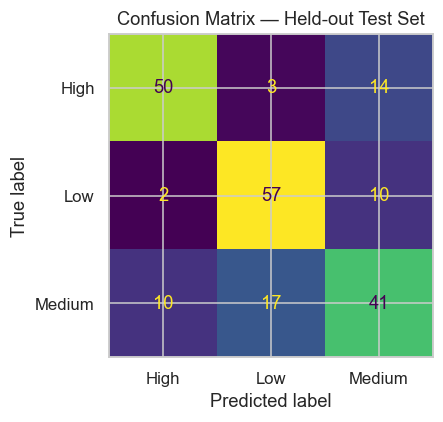

In [19]:
y_pred = pipe.predict(X_test)

print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — Held-out Test Set")
plt.tight_layout()
plt.show()

In [20]:
def score_supplier(industry_name: str, naics_code) -> dict:
    """Return emission risk tier and class probabilities for a new supplier."""
    sector2 = str(naics_code)[:2]
    row = pd.DataFrame({"industry": [industry_name], "sector2": [sector2]})
    tier  = pipe.predict(row)[0]
    probs = dict(zip(pipe.classes_, pipe.predict_proba(row)[0].round(3)))
    return {"tier": tier, "probabilities": probs}

examples = [
    ("Coal Mining",                    "21"),
    ("Software Publishers",            "51"),
    ("Cattle Ranching and Farming",    "11"),
    ("Hospitals",                      "62"),
    ("Petroleum and Natural Gas",      "21"),
    ("Commercial Banking",             "52"),
    ("Plastics Product Manufacturing", "32"),
    ("Trucking",                       "48"),
]

print(f"{'Industry':<44} {'Tier':<8}  Low    Med    High")
print("-" * 78)
for name, code in examples:
    r = score_supplier(name, code)
    p = r["probabilities"]
    lo, me, hi = p.get("Low", 0), p.get("Medium", 0), p.get("High", 0)
    print(f"{name:<44} {r['tier']:<8}  {lo:.3f}  {me:.3f}  {hi:.3f}")

Industry                                     Tier      Low    Med    High
------------------------------------------------------------------------------
Coal Mining                                  High      0.042  0.036  0.922
Software Publishers                          Low       0.922  0.046  0.032
Cattle Ranching and Farming                  High      0.027  0.071  0.902
Hospitals                                    Medium    0.391  0.566  0.042
Petroleum and Natural Gas                    High      0.040  0.029  0.931
Commercial Banking                           Low       0.842  0.131  0.027
Plastics Product Manufacturing               High      0.019  0.152  0.829
Trucking                                     High      0.046  0.237  0.716
